In [1]:
import torch

In [2]:
from torch.utils.data import DataLoader
from torchvision import transforms

from entrega_3.utils.art_dataset import prepare_data_splits, ArtDataset, plot_art_grid
from entrega_3.utils.difussion import DiffusionScheduler, MiniUNetCond, train_diffusion

diffusion_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
ROOT_DIRECTORY = "../../data/emoart-5k/images-selected"
MACRO_CLASSES=['abstract', 'classic', 'fluid', 'graphic']

train_list, _, _ = prepare_data_splits(ROOT_DIRECTORY, MACRO_CLASSES)

print(f"Total Train: {len(train_list)}")

ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

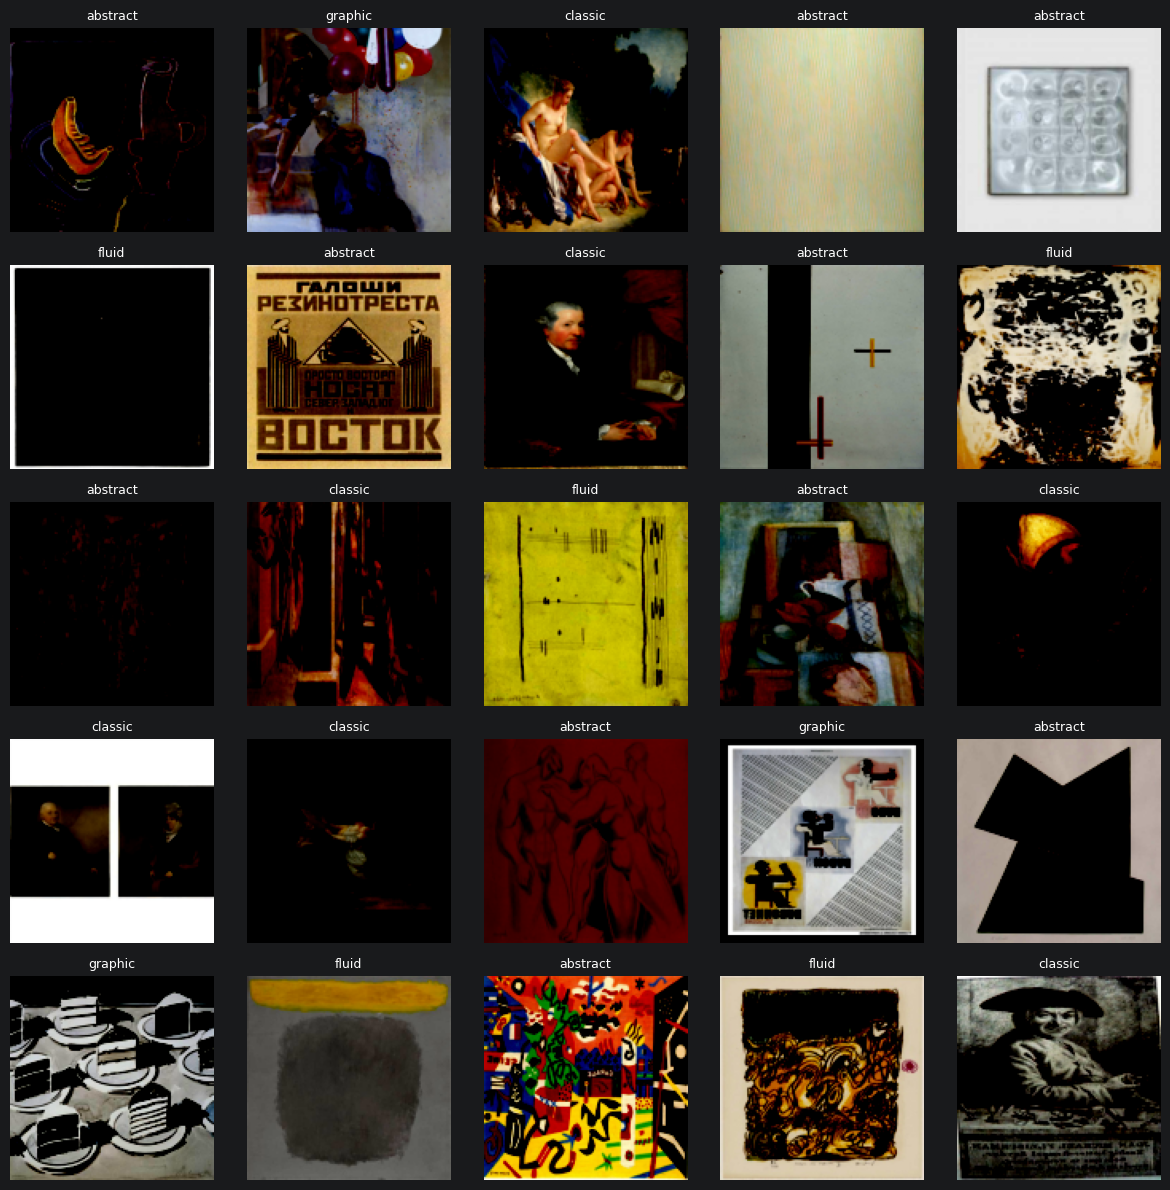

In [4]:
train_dataset = ArtDataset(train_list, transform=diffusion_transforms)

# Take a sample
plot_art_grid(train_dataset)

In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0,drop_last=True)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciar el Scheduler y el Modelo
scheduler = DiffusionScheduler(timesteps=300, device=device)
mini_unet = MiniUNetCond(num_classes=4).to(device)

Epoch 1/30 -> Loss de Difusión: 0.40763
Epoch 2/30 -> Loss de Difusión: 0.15198
Epoch 3/30 -> Loss de Difusión: 0.13009
Epoch 4/30 -> Loss de Difusión: 0.11703
Epoch 5/30 -> Loss de Difusión: 0.09851


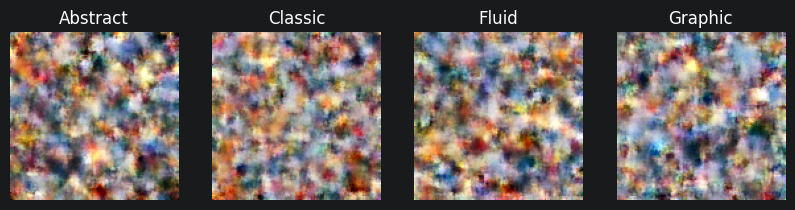

Epoch 6/30 -> Loss de Difusión: 0.09849
Epoch 7/30 -> Loss de Difusión: 0.09719
Epoch 8/30 -> Loss de Difusión: 0.08406
Epoch 9/30 -> Loss de Difusión: 0.08272
Epoch 10/30 -> Loss de Difusión: 0.08406


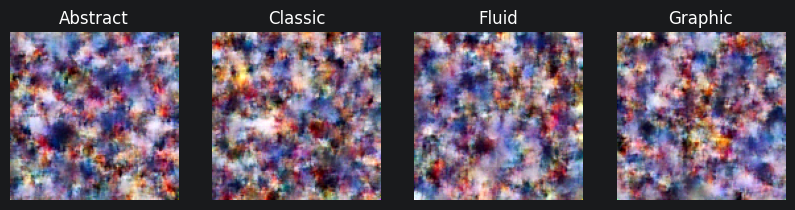

Epoch 11/30 -> Loss de Difusión: 0.07978
Epoch 12/30 -> Loss de Difusión: 0.07747
Epoch 13/30 -> Loss de Difusión: 0.07527
Epoch 14/30 -> Loss de Difusión: 0.08042
Epoch 15/30 -> Loss de Difusión: 0.07036


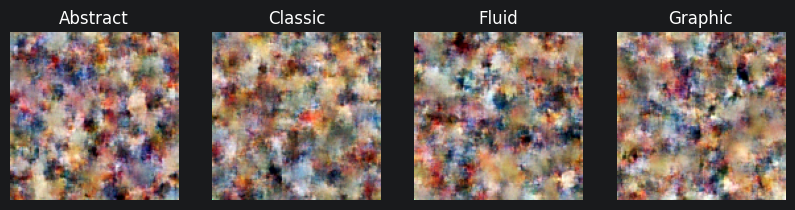

KeyboardInterrupt: 

In [7]:
history_diff = train_diffusion(mini_unet, scheduler, train_loader, device, epochs=30, timesteps=300, classes=MACRO_CLASSES)